# Análisis Exploratorio de Datos — MetroPT3

Dataset de telemetría de un compresor de aire del metro de Porto.  
Contiene **8 sensores analógicos** y **7 sensores digitales** muestreados cada ~10 segundos durante varios meses de 2020.

**Objetivo:** entender la estructura, distribuciones y propiedades temporales de los datos crudos, *Desúés se le hace el preprocesamiento que aqui encuentro necesario y la transformación con etiquetado de fallas*.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

sns.set_style('whitegrid')

ANALOG_COLS  = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
                'Oil_temperature', 'Motor_current', 'Caudal_impulses']
BINARY_COLS  = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
                'Pressure_switch', 'Oil_level']

In [15]:
df = pd.read_csv('../data/raw/MetroPT3(AirCompressor).csv',
                parse_dates=['timestamp'])
df.drop(columns=['Unnamed: 0'], inplace=True)
df = df.sort_values('timestamp').reset_index(drop=True)
df.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 1. Estructura y calidad del dataset

In [16]:
print(f"Filas y columnas : {df.shape}")
print(f"Rango temporal   : {df['timestamp'].min()}  hasta  {df['timestamp'].max()}")
print(f"Duración total   : {df['timestamp'].max() - df['timestamp'].min()}")

Filas y columnas : (1516948, 16)
Rango temporal   : 2020-02-01 00:00:00  hasta  2020-09-01 03:59:50
Duración total   : 213 days 03:59:50


### Frecuencia de muestreo

In [17]:
deltas = df['timestamp'].diff().dropna()
print('Frecuencia de muestreos')
print(f' Mediana : {deltas.median()}')
print(f' Minimo  : {deltas.min()}')
print(f' Maximo  : {deltas.max()}')

Frecuencia de muestreos
 Mediana : 0 days 00:00:10
 Minimo  : 0 days 00:00:08
 Maximo  : 2 days 00:01:58


### Espacios significativos entre cada muestreo

In [18]:
gaps = deltas[deltas > pd.Timedelta('1min')].sort_values(ascending=False)
print(f'Gaps > a 1 min: {len(gaps)}')
if len(gaps):
    print(gaps.head(10))

Gaps > a 1 min: 331
618538    2 days 00:01:58
1055664   1 days 12:14:36
214850    1 days 04:03:01
1318888   1 days 00:40:33
805415    1 days 00:34:51
1126187   0 days 23:56:00
1454438   0 days 23:39:17
708881    0 days 22:17:41
908125    0 days 21:28:25
450114    0 days 20:43:37
Name: timestamp, dtype: timedelta64[us]


Valores nulos o Duplicados

In [19]:
print(f'Nulos      : {df.isnull().sum()}')
print(f'\nDupolicados: {df.duplicated().sum()}')

Nulos      : timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64



Dupolicados: 0


## 2. Propiedades estadísticas

In [20]:
print('Sensores ANALÓGICOS')
display(df[ANALOG_COLS].describe()
        .T.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'min', 'max'])
        .format(precision=4))

Sensores ANALÓGICOS


,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0000,1.3678,3.2509,-0.0320,-0.0140,-0.0120,-0.0100,10.6760
TP3,1516948.0000,8.9846,0.6391,0.7300,8.4920,8.9600,9.4920,10.3020
H1,1516948.0000,7.5682,3.3332,-0.0360,8.2540,8.7840,9.3740,10.2880
DV_pressure,1516948.0000,0.0560,0.3824,-0.0320,-0.0220,-0.0200,-0.0180,9.8440
Reservoirs,1516948.0000,8.9852,0.6383,0.7120,8.4940,8.9600,9.4920,10.3000
Oil_temperature,1516948.0000,62.6442,6.5163,15.4000,57.7750,62.7000,67.2500,89.0500
Motor_current,1516948.0000,2.0502,2.3021,0.0200,0.0400,0.0450,3.8075,9.2950
Caudal_impulses,1516948.0000,0.9371,0.2428,0.0000,1.0000,1.0000,1.0000,1.0000


Sensores Binarios

In [21]:
print('Sensores binarios')
print(BINARY_COLS)
binary_stats = pd.DataFrame({
    'Activo (%)' : (df[BINARY_COLS].mean() * 100).round(2),
    'n_activo'   : (df[BINARY_COLS].sum().astype(int)),
    'n_inactivo' : (df[BINARY_COLS].sum().astype(int))
})
display(binary_stats.style.background_gradient(cmap='Oranges', subset=['Activo (%)']))

Sensores binarios
['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level']


,Activo (%),n_activo,n_inactivo
COMP,83.700000,1269620,1269620
DV_eletric,16.060000,243638,243638
Towers,91.980000,1395362,1395362
MPG,83.270000,1263108,1263108
LPS,0.340000,5188,5188
Pressure_switch,99.140000,1503958,1503958
Oil_level,90.420000,1371557,1371557


**COMP -  VÁLVULA DE ADMISIÓN DEL AIRE:** 
-   (1) Activa: No hay admisión de aire y el compresor está apagado
-   (0) Inactiva: Si hay adisión de airte y el compresor trabaja bajo carga

**MPG - ARRANQUE BAJO CARGA:** 
-   (1) La presion en APU cayó por debajo de 8.2 bar y se activa la válvula de admision COMP
-   (0) Presion normal, no se necesita arrancar

**DV_Electric - VALCULA DE SALIDA DEL COMRPESOR:** Es la señal más directa para saber si se está trabajando
-   (1) Activa: Compresor funcionando bajo carga
-   (0) Inactiva: Compresor apagado

**TOWERS - SELECCIÓN DE TORRE SECADORA:** Es la señal más directa para saber si se está trabajando
-   (1) Torre 2 secando el aire
-   (0) Torre 1 secando el aire

**PS -Descarga torres secadoras:** 
-   (1) Hay descarga de humedad en las torres de secado
-   (0) Operación normal de torres

**LPS - Low Pressure Switch:** Si esto se activa cada vez mas frecuentemente se puede tratar de una degradación o fuga
-   (1) La presión cayó por debajo de y bar
-   (0) Presion normal >= 7 bar

**OIL LEVEL** 
-   (1) Nivel de aceite bajo
-   (0) NIvel de aceite normal

## 3. Distribuciones de sensores analógicos

Histogramas con KDE.
- ROJO : media
- VERDE: mediana

Distribuciones bimodales indican  que el compresor puede tener al menos dos modos de operación.

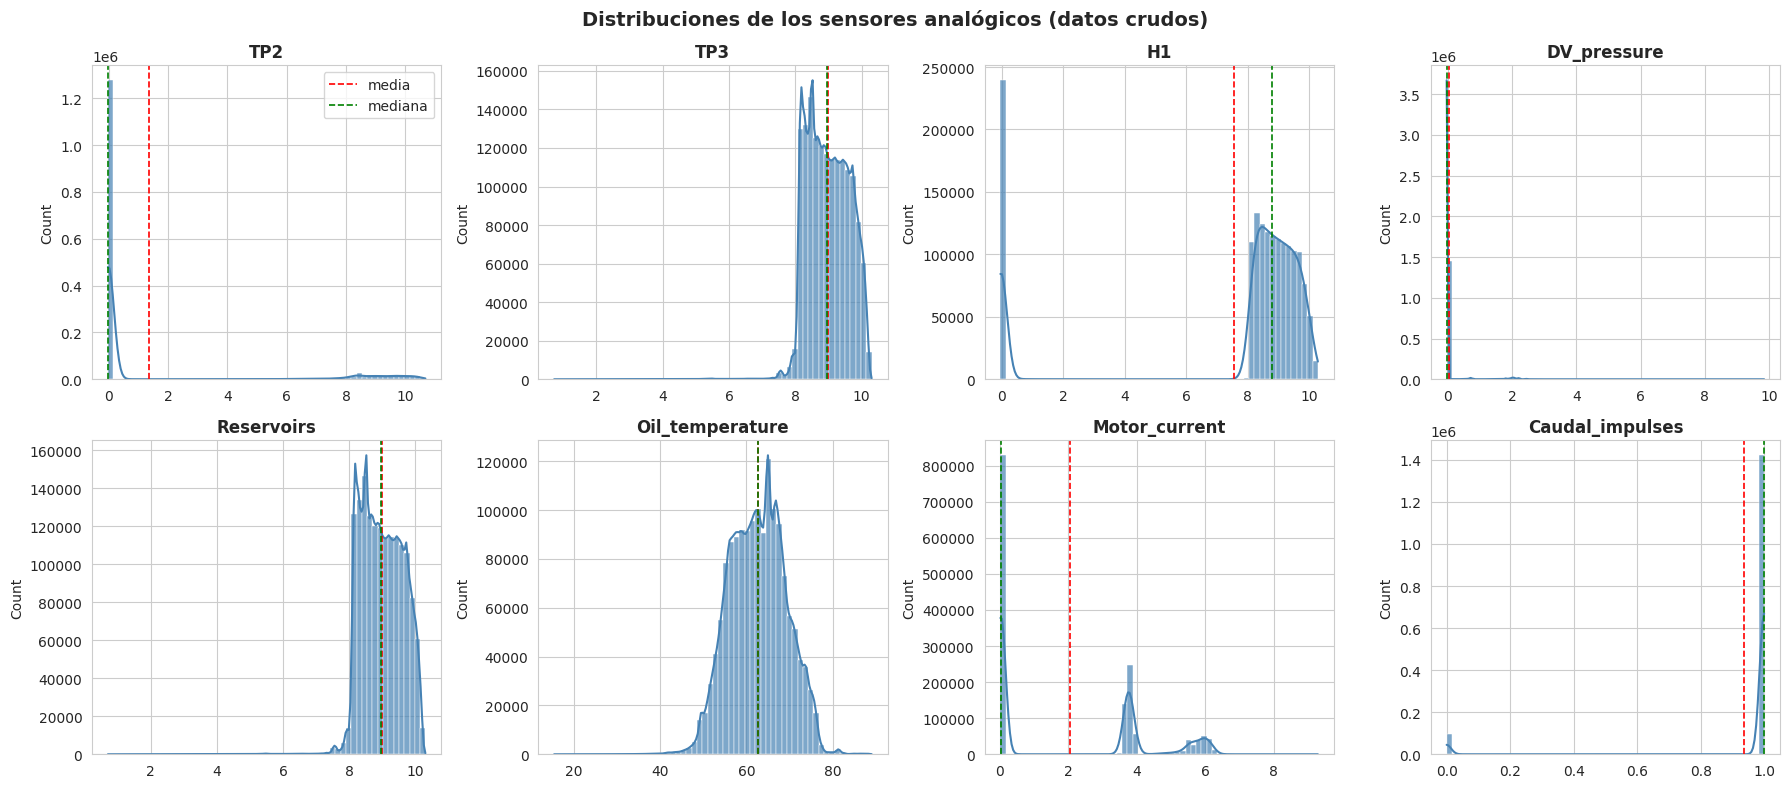

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, ANALOG_COLS):
    sns.histplot(df[col], bins=60, kde=True, ax=ax, color='steelblue', alpha=0.7)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.2, label='media')
    ax.axvline(df[col].median(), color='green',  linestyle='--', linewidth=1.2, label='mediana')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

axes[0].legend(fontsize=10)
plt.suptitle('Distribuciones de los sensores analógicos (datos crudos)', fontsize=14, fontweight='bold')
plt.tight_layout()

**TP2 -  PRESION DEL COMPRESOR:** Tiene una gran cantidad de valores en 0 pero en la realidad se plasma el compotamiento que tiene este equipo, estando apagado la mayoría del tiempo y trabajando con valores de presión de 8 a 10 bar. No significa que sean outliers.

**TP3 y Reservoirs:** Son el panel de presión neumático y una reserva. Los dos siempre están operando constantemente en valores de 8 a 10 bar y en el artículo está especificado que sus valores deben ser muy similares. Tienen un ligero sesgo positivo.

**H1 - Caída de presión del filtro ciclónico:** Al igual que la presión del compresor, se muestra que la mayor parte del tiempo este filtro se encuentra apagado, pero durante su operación se trabaja con valroes de presión de 7 a 10 Bar.

**DV_pressure - Caída en torres secadoras:** Practicamente siempre tiene un valor de 0, y en el paper dice que significa que el compresor está trabajando bajo carga.

**Motor_current - Corriente del motor:** Todos los valores en 0 indican que el motor está apagado, pero también se puede apreciar que existen picos al rededor de 4 y de 7 Amperes. Prácticamente esto es una variable categórica disfrazada de contínua:
*   0A motor apagado
*   4A motor trabajando sin carga
*   7A motor trabajando bajo carga
*   9A en el arranque

**Oil_temperature:** Temperatura del aceite del compresor, tiene una media de 62 grados y es aproximadamente normal. Esta es importante para RUL poruqe los cambios graduales en la temperatura del aceite van indicando una degradación presente.

**Caudal_impulses - Pulsos en el flujo de aire:** Parece más una señal binaria con valroes en 0 y 1. FUnciona más como una indicadora de estado porque ((( 0  significa que se está apagado.)))



## > Régimenes de operación.
| Estado          | COMP | DV_electric | MPG | LPS                       | Motor_current |
|----------------|------|-------------|-----|---------------------------|---------------|
| APAGADO        | 1    | 0           | 1   | 0 o 1 (depende presión residual) | ≈ 0 A         |
| SIN CARGA (offloaded) | 1    | 0           | 1   | —                        | ≈ 4 A         |
| BAJO CARGA (operación normal) | 0    | 1           | 0   | 0                        | ≈ 7 A         |

Para la estimación del RUL solamente es útil el régimen 2 en ooperación porque en realidad solamente existe un desgaste en el sistema cuando este se encuentra activo. Para poder encontrar la frontera de esos 2 régimenes, hay qeu usar que la corriente sea > 2 y usar los datos unicamente cuando se sabe que el sistema está en operación.

## 3. Sensores binarios — activación y comportamiento temporal

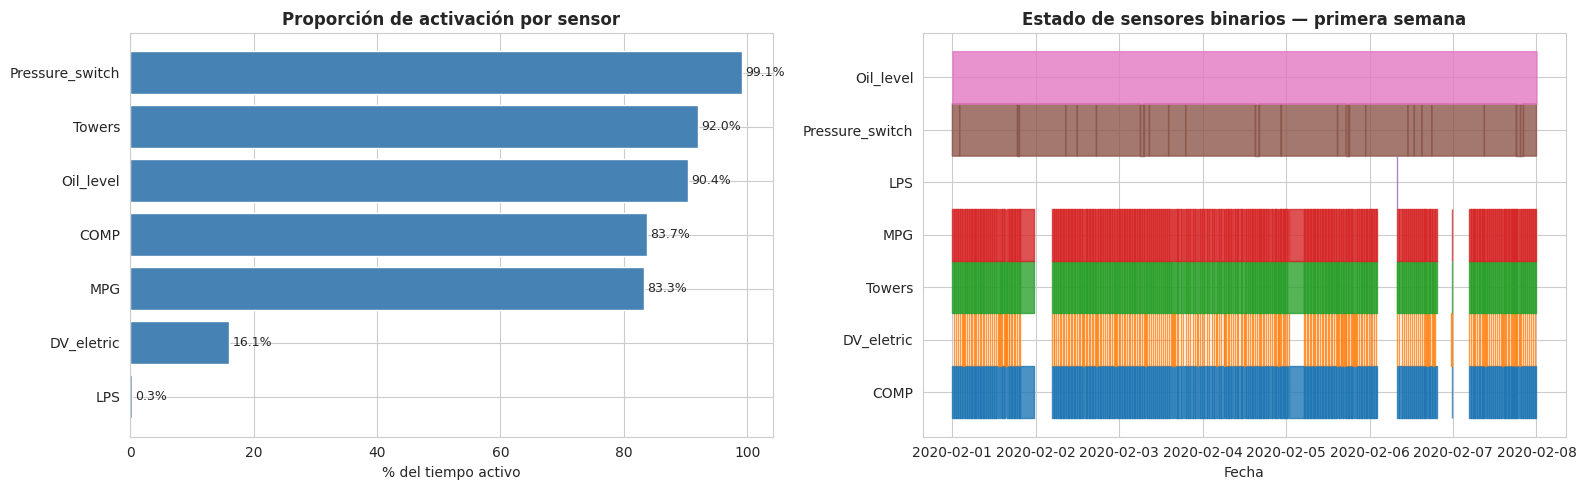

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Izquierda: proporción activa por sensor
proportions = df[BINARY_COLS].mean().sort_values() * 100
axes[0].barh(proportions.index, proportions.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('% del tiempo activo')
axes[0].set_title('Proporción de activación por sensor', fontweight='bold')
for i, v in enumerate(proportions.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# Derecha: estado de los sensores en la primera semana (vista tipo Gantt)
week = df[df['timestamp'] < df['timestamp'].min() + pd.Timedelta('7D')].copy()
colors = plt.cm.tab10.colors
for i, col in enumerate(BINARY_COLS):
    on_mask = week[col] == 1
    axes[1].fill_between(week['timestamp'], i + week[col], i,
                        where=on_mask, color=colors[i], alpha=0.8, label=col)

axes[1].set_yticks(np.arange(len(BINARY_COLS)) + 0.5)
axes[1].set_yticklabels(BINARY_COLS)
axes[1].set_title('Estado de sensores binarios — primera semana', fontweight='bold')
axes[1].set_xlabel('Fecha')

plt.tight_layout()

## 4. Series de tiempo completas

Vista de los datos crudos a lo largo de todo el período de registro.

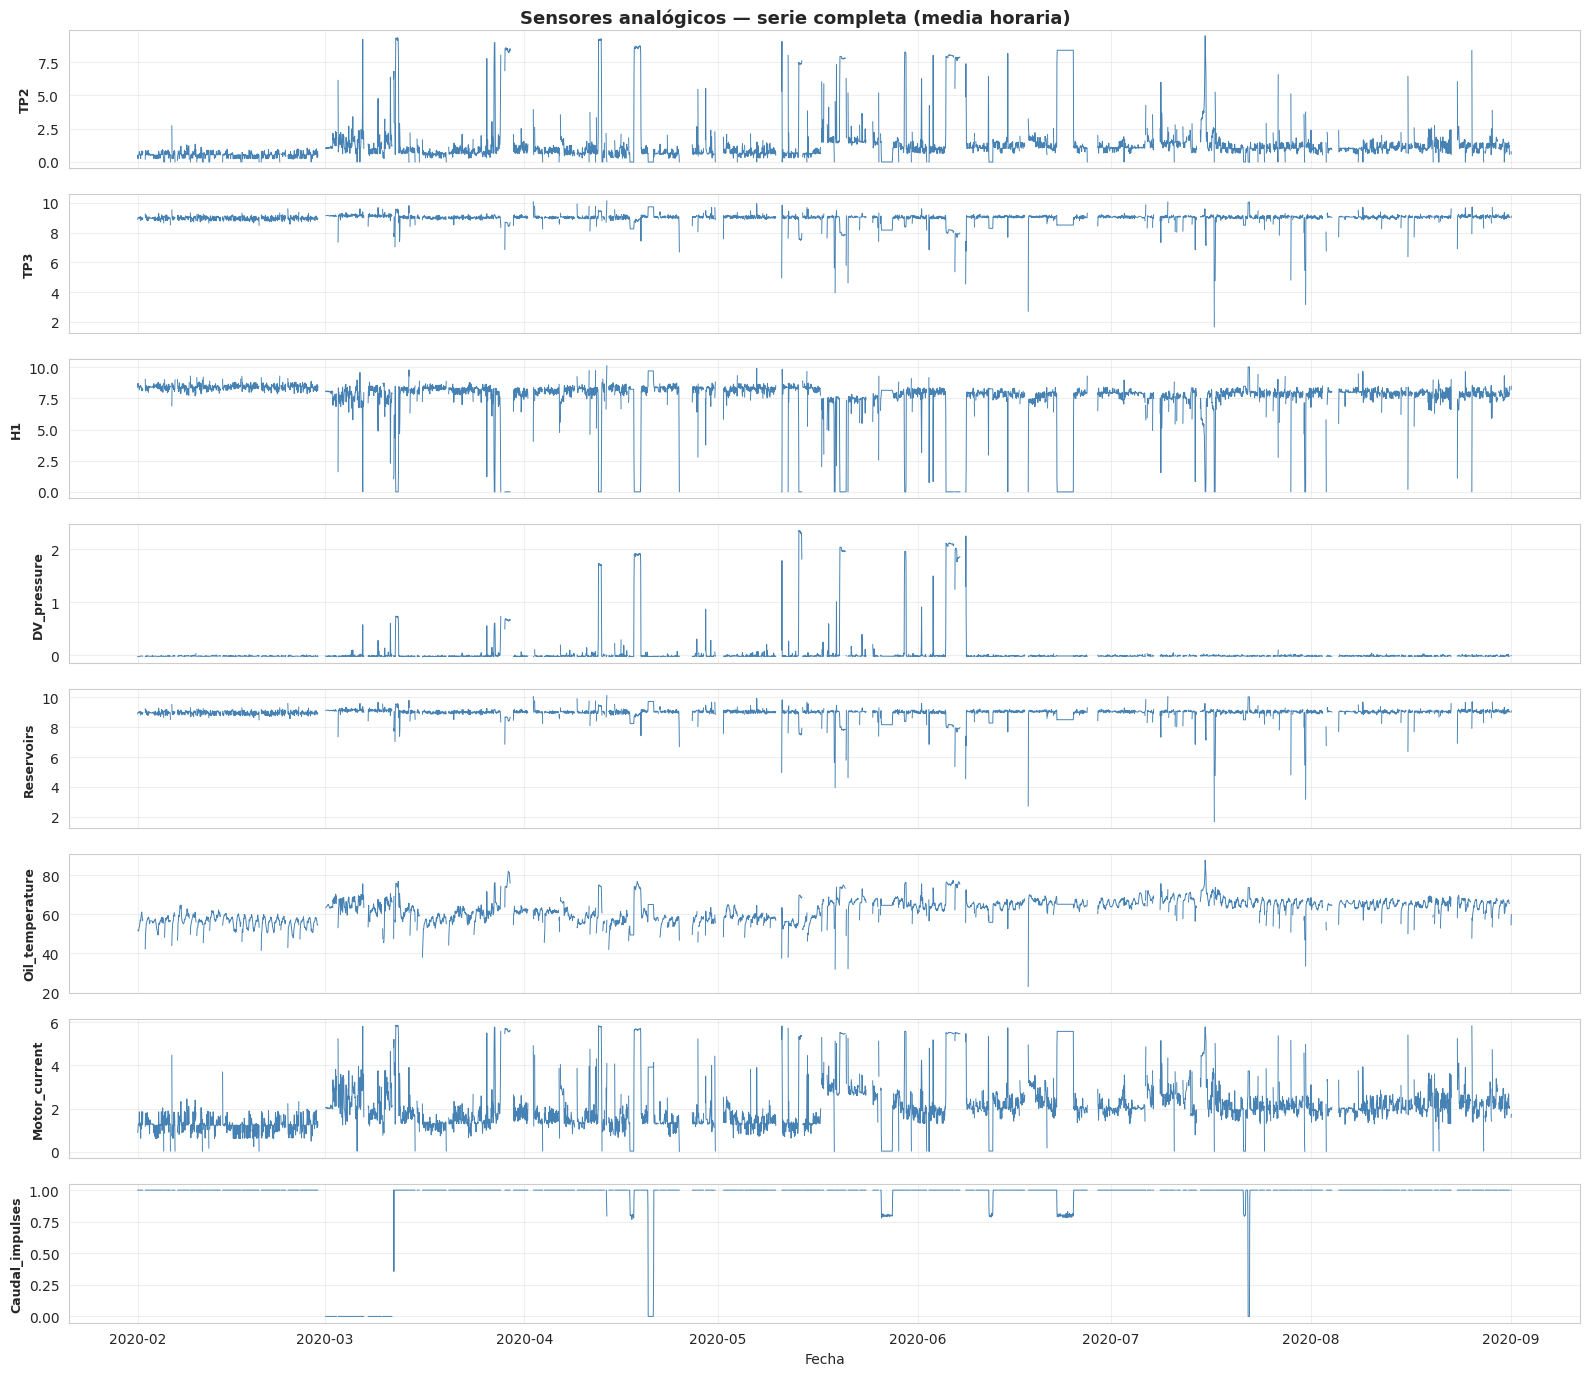

In [24]:
# Resampleo horario solo para visualización (los datos originales son cada ~10 s)
df_h = df.set_index('timestamp')[ANALOG_COLS].resample('1h').mean().reset_index()

fig, axes = plt.subplots(len(ANALOG_COLS), 1, figsize=(16, 14), sharex=True)

for ax, col in zip(axes, ANALOG_COLS):
    ax.plot(df_h['timestamp'], df_h[col], linewidth=0.7, color='steelblue')
    ax.set_ylabel(col, fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha')
plt.suptitle('Sensores analógicos — serie completa (media horaria)', fontsize=13, fontweight='bold')
plt.tight_layout()

## 5. Correlación entre sensores

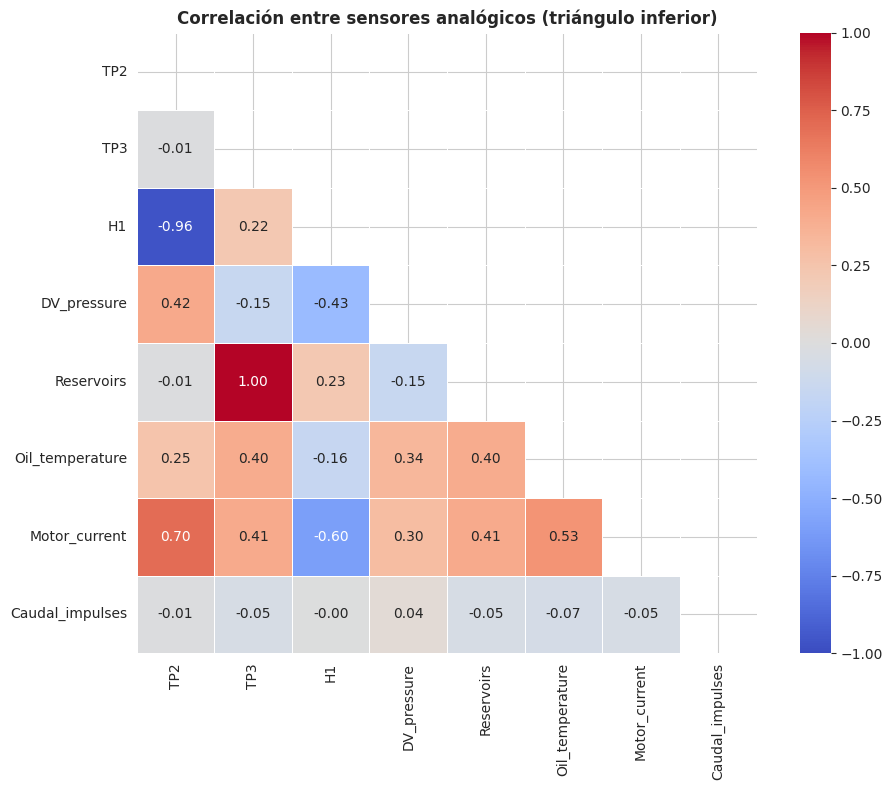

In [25]:
corr = df[ANALOG_COLS].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            mask=mask, square=True, linewidths=0.5)
plt.title('Correlación entre sensores analógicos (triángulo inferior)', fontweight='bold')
plt.tight_layout()

## 6. Autocorrelación — memoria temporal de los sensores

El ACF indica cuántos pasos hacia atrás "recuerda" cada sensor.  
Esto define si los modelos necesitarán ventanas temporales (rolling features, LSTM, etc.).

In [26]:
# key_sensors = ['TP2', 'TP3', 'Oil_temperature', 'Motor_current']
# LAGS = 200  # ~33 minutos a 10 s por muestra

# fig, axes = plt.subplots(2, 2, figsize=(20, 15))
# axes = axes.flatten()

# for ax, col in zip(axes, key_sensors):
#     plot_acf(df[col].dropna(), lags=LAGS, ax=ax, color='steelblue',
#             alpha=0.05, zero=False)
#     ax.set_title(f'ACF — {col}', fontweight='bold')
#     ax.set_xlabel('Lag (× 10 s)')
#     ax.set_ylabel('Autocorrelación')

# plt.suptitle('Función de Autocorrelación — sensores clave', fontsize=13, fontweight='bold')
# plt.tight_layout()